# Поездки на желтом такси в Нью-Йорке за январь 2015 года

#### Цели и задачи:
- Провести Разведочный анализ данных
- Описание датасета
- Определение важности признаков
- Кластеризация 
- Создание моделей классификации
- Создание дашборда

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as  plt
%matplotlib inline

In [2]:
vgs = pd.read_csv("yellow_tripdata_2015-01.csv")
vgs.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.00,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.00,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.00,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.00,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.00,0.3,16.30
5,1,2015-01-10 20:33:39,2015-01-10 20:53:52,1,9.00,-73.874374,40.774048,1,N,-73.986977,40.758194,1,27.0,0.5,0.5,6.70,5.33,0.3,40.33
6,1,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.20,-73.983276,40.726009,1,N,-73.992470,40.749634,2,14.0,0.5,0.5,0.00,0.00,0.3,15.30
7,1,2015-01-10 20:33:39,2015-01-10 20:42:20,3,0.80,-74.002663,40.734142,1,N,-73.995010,40.726326,1,7.0,0.5,0.5,1.66,0.00,0.3,9.96
8,1,2015-01-10 20:33:39,2015-01-10 21:11:35,3,18.20,-73.783043,40.644356,2,N,-73.987595,40.759357,2,52.0,0.0,0.5,0.00,5.33,0.3,58.13
9,1,2015-01-10 20:33:40,2015-01-10 20:40:44,2,0.90,-73.985588,40.767948,1,N,-73.985916,40.759365,1,6.5,0.5,0.5,1.55,0.00,0.3,9.35


#### Описание данных

- VendorID — ID перевозчика

- tpep_pickup_datetime — Дата и время посадки

- tpep_dropoff_datetime — Дата и время высадки

- passenger_count — Количество пассажиров

- trip_distance — Расстояние поездки

- pickup_longitude — Долгота посадки

- pickup_latitude — Широта посадки

- RateCodeID — Код тарифа

- store_and_fwd_flag — Флаг отправки

- dropoff_longitude — Долгота высадки

- dropoff_latitude — Широта высадки

- payment_type — Способ оплаты

- fare_amount — Стоимость проезда

- extra — Дополнительная плата

- mta_tax — Налог MTA

- tip_amount — Сумма чаевых

- tolls_amount — Сумма дорожных сборов (плата за проезд по платным дорогам)

- improvement_surcharge — Надбавка за улучшение сервиса

- total_amount — Итоговая сумма

## Разведочный анализ данных

##### Размерность и краткая информация о наборе данных

In [3]:
vgs.shape

(12748986, 19)

In [4]:
vgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12748986 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.8+ GB


In [5]:
vgs.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

##### Краткая статистическая информация по набору данных

In [6]:
vgs.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274899e+07,1.274898e+07,1.274899e+07
mean,1.521437e+00,1.681491e+00,1.345913e+01,-7.256184e+01,3.997282e+01,1.036901e+00,-7.260904e+01,3.999961e+01,1.386712e+00,1.190566e+01,3.082790e-01,4.977986e-01,1.853814e+00,2.434984e-01,2.831431e-01,1.510829e+01
std,4.995402e-01,1.337924e+00,9.844094e+03,1.012510e+01,5.578691e+00,6.732240e-01,9.966037e+00,5.487742e+00,4.988611e-01,1.030254e+01,5.916643e-01,3.534229e-02,1.106432e+03,1.527171e+00,6.908633e-02,1.106503e+03
min,1.000000e+00,0.000000e+00,0.000000e+00,-1.219258e+02,0.000000e+00,1.000000e+00,-7.401667e+02,-9.029157e+00,1.000000e+00,-4.500000e+02,-7.900000e+01,-5.000000e-01,-9.242000e+01,-2.600000e+01,0.000000e+00,-4.503000e+02
25%,1.000000e+00,1.000000e+00,1.000000e+00,-7.399168e+01,4.073554e+01,1.000000e+00,-7.399120e+01,4.073436e+01,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.160000e+00
50%,2.000000e+00,1.000000e+00,1.680000e+00,-7.398160e+01,4.075314e+01,1.000000e+00,-7.397976e+01,4.075362e+01,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01
75%,2.000000e+00,2.000000e+00,3.000000e+00,-7.396662e+01,4.076757e+01,1.000000e+00,-7.396246e+01,4.076880e+01,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.060000e+00,0.000000e+00,3.000000e-01,1.630000e+01
max,2.000000e+00,9.000000e+00,1.542000e+07,7.866265e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,5.000000e+00,4.008000e+03,9.999900e+02,5.000000e-01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06


In [7]:
vgs.describe(include = "object")

,tpep_pickup_datetime,tpep_dropoff_datetime,store_and_fwd_flag
count,12748986,12748986,12748986
unique,2438284,2442163,2
top,2015-01-05 09:39:49,2015-01-02 00:00:00,N
freq,94,142,12633953


##### Проверка набора данных на наличие пропущенных и дублирующих значений

In [8]:
vgs.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
dtype: int64

In [9]:
vgs = vgs.dropna()

In [10]:
vgs.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [11]:
print(int(vgs.isnull().sum().all()))

0


#### Работа над аномальными данными

In [12]:
#Количество пассажиров должно быть от 1 до 6
vgs = vgs[(vgs['passenger_count'] >= 1) & (vgs['passenger_count'] <= 6)]

In [13]:
#Стоимость проезда должна быть положительной
vgs = vgs[vgs['fare_amount'] > 0]

In [14]:
#Итоговая сумма должна быть положительной
vgs = vgs[vgs['total_amount'] > 0]

In [15]:
#Чаевые не должны быть отрицательными
vgs = vgs[vgs['tip_amount'] >= 0]

In [16]:
#Плата за дороги не должна быть отрицательной
vgs = vgs[vgs['tolls_amount'] >= 0]

In [17]:
# Удалим нереалистично большие расстояния, например, больше 100 миль
max_distance = 100
vgs = vgs[vgs['trip_distance'] <= max_distance]

In [18]:
vgs.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07,1.273462e+07
mean,1.521627e+00,1.682309e+00,2.783497e+00,-7.256708e+01,3.997571e+01,1.034881e+00,-7.261534e+01,4.000308e+01,1.385886e+00,1.191567e+01,3.085895e-01,4.982581e-01,1.854309e+00,2.431896e-01,2.831474e-01,1.511949e+01
std,4.995321e-01,1.337673e+00,3.382780e+00,1.010671e+01,5.568558e+00,5.863009e-01,9.943517e+00,5.475327e+00,4.973197e-01,1.028189e+01,5.905855e-01,2.946079e-02,1.107056e+03,1.524772e+00,6.907807e-02,1.107127e+03
min,1.000000e+00,1.000000e+00,0.000000e+00,-1.219258e+02,0.000000e+00,1.000000e+00,-7.401667e+02,-9.029157e+00,1.000000e+00,1.000000e-02,-2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-02
25%,1.000000e+00,1.000000e+00,1.000000e+00,-7.399168e+01,4.073555e+01,1.000000e+00,-7.399120e+01,4.073437e+01,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.190000e+00
50%,2.000000e+00,1.000000e+00,1.680000e+00,-7.398160e+01,4.075314e+01,1.000000e+00,-7.397976e+01,4.075363e+01,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01
75%,2.000000e+00,2.000000e+00,3.000000e+00,-7.396663e+01,4.076758e+01,1.000000e+00,-7.396246e+01,4.076881e+01,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.060000e+00,0.000000e+00,3.000000e-01,1.630000e+01
max,2.000000e+00,6.000000e+00,1.000000e+02,7.866265e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,5.000000e+00,4.008000e+03,9.999900e+02,5.000000e-01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06


In [19]:
#Количество уникальных значений в стоблце "Код тарицфа"
vgs['RateCodeID'].nunique()

7

In [20]:
vgs['RateCodeID'].value_counts(normalize=False).plot.bar()

<Axes: xlabel='RateCodeID'>

 Видим столбец 99, это явно аномальные значения, от которых нужно избавиться.

In [21]:
(vgs['RateCodeID'] == 99).sum()

np.int64(366)

In [22]:
vgs = vgs[vgs['RateCodeID'] != 99]

In [23]:
vgs['RateCodeID'].nunique()

6

In [24]:
vgs['RateCodeID'].value_counts(normalize=False).plot.bar()

<Axes: xlabel='RateCodeID'>

На графике видно, что подавляющее большинство поездок совершалось по стандартному тарифу RateCodeID = 1, остальные тарифы встречаются намного реже, поэтому можно сказать, что основной тариф — стандартный

In [25]:
#Количество уникальных значений в стоблце "Флаг отправки"
vgs['store_and_fwd_flag'].nunique()

2

In [26]:
#Количество уникальных значений в стоблце "Способ оплаты"

In [27]:
vgs['payment_type'].nunique()

5

In [28]:
vgs['payment_type'].value_counts(normalize=False).plot.bar()

<Axes: xlabel='payment_type'>

На графике можно увидеть следующие способы оплаты:
- Тип 1 (Credit card) — около 8 млн поездок, оплата картой (самый популярный способ)
- Тип 2 (Cash) — около 3.5 млн поездок, оплата наличными
- Тип 3 (No charge) — без оплаты (очень редко)
- Тип 4 (Dispute) — спорная оплата (единичные случаи)
- Тип 5 (Unknown) — неизвестный тип оплаты (редко)

(Unknown) — неизвестный тип оплаты - означает, что в системе не указан способ оплаты. Скорее всего это является сбоем при записи, поэтому необходимо избавиться от этого типа

In [29]:
# Удаляем строки с типом оплаты 5 (Unknown)
vgs = vgs[vgs['payment_type'] != 5]

# Проверяем, что осталось
print(vgs['payment_type'].value_counts())
print(f"Осталось строк: {len(vgs)}")

payment_type
1    7876298
2    4811839
3      36241
4       9873
Name: count, dtype: int64
Осталось строк: 12734251


In [30]:
vgs['payment_type'].value_counts(normalize=False).plot.bar()

<Axes: xlabel='payment_type'>

На графике видно, что чаще всего пассажиры оплачивают поездку картой (1) — около 8 млн поездок. 
На втором месте наличные (2) — примерно 3.5 млн.
Остальные типы оплаты (без оплаты, спорные) встречаются редко и сильно выделяются на фоне основных.

In [31]:
vgs['passenger_count'].nunique()

6

In [32]:
vgs['passenger_count'].value_counts().sort_index()

passenger_count
1    8988220
2    1813436
3     528121
4     253002
5     697148
6     454324
Name: count, dtype: int64

In [33]:
vgs['passenger_count'].value_counts(normalize=False).plot.bar()

<Axes: xlabel='passenger_count'>

In [34]:
vgs['fare_amount'].nunique()

1877

In [35]:
#Средняя стоимость проезда
avg_fare = vgs['fare_amount'].mean()
print(f"Средняя стоимость поездки: ${avg_fare:.2f}")

Средняя стоимость поездки: $11.92


In [36]:
print(f"Мин: ${vgs['fare_amount'].min():.2f}")
print(f"Макс: ${vgs['fare_amount'].max():.2f}")

Мин: $0.01
Макс: $4008.00


In [37]:
#Среднее расстояние поездки
vgs['trip_distance'].mean()

np.float64(2.783466320084314)

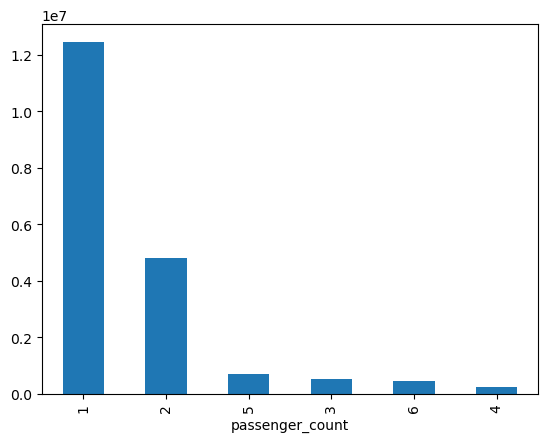

<Figure size 1000x600 with 0 Axes>

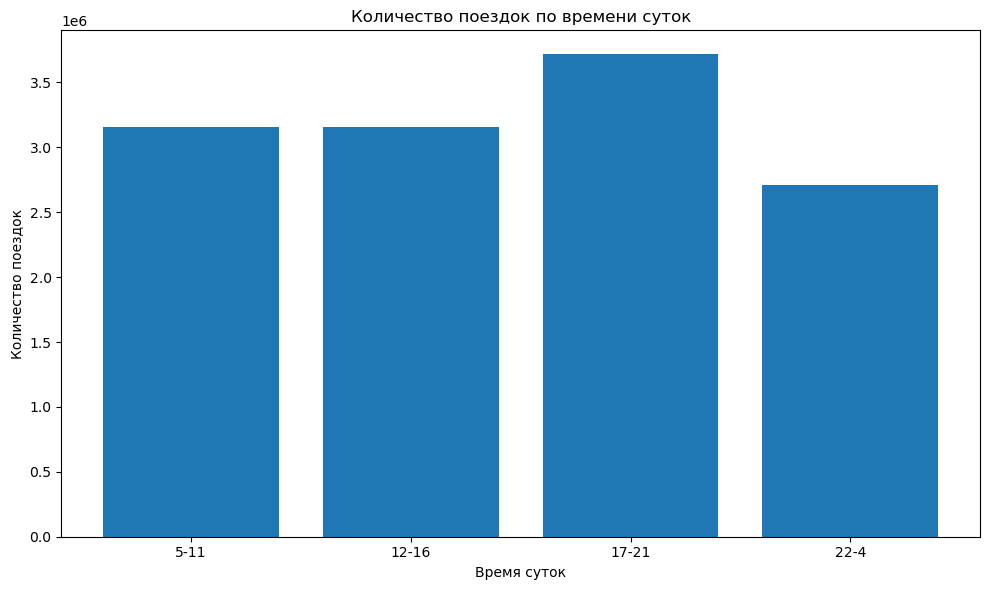

In [39]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return '5-11'
    elif 12 <= hour < 17:
        return '12-16'
    elif 17 <= hour < 22:
        return '17-21'
    else:
        return '22-4'
vgs['pickup_hour'] = pd.to_datetime(vgs['tpep_pickup_datetime']).dt.hour
vgs['time_of_day'] = vgs['pickup_hour'].apply(get_time_of_day)

time_order = ['5-11', '12-16', '17-21', '22-4']

plt.figure(figsize=(10, 6))
time_counts = vgs['time_of_day'].value_counts()
time_counts = time_counts.reindex(time_order)

plt.bar(time_counts.index, time_counts.values)

plt.title('Количество поездок по времени суток')
plt.xlabel('Время суток')
plt.ylabel('Количество поездок')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

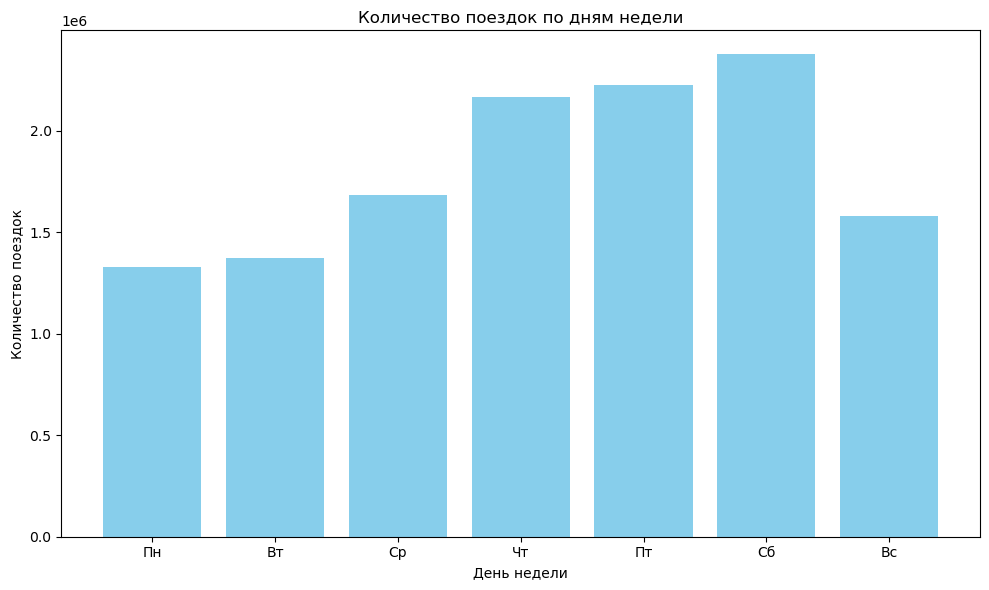

In [51]:
plt.figure(figsize=(10, 6))
vgs['pickup_weekday'] = pd.to_datetime(vgs['tpep_pickup_datetime']).dt.dayofweek
weekday_counts = vgs['pickup_weekday'].value_counts().sort_index()
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.bar(weekday_names, weekday_counts.values, color='skyblue')
plt.title('Количество поездок по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.tight_layout()
plt.show()

Больше всего поездок приходится на субботу, затем на пятницу и четверг. В воскресенье активность падает, а в начале недели (пн-ср) поездок заметно меньше.

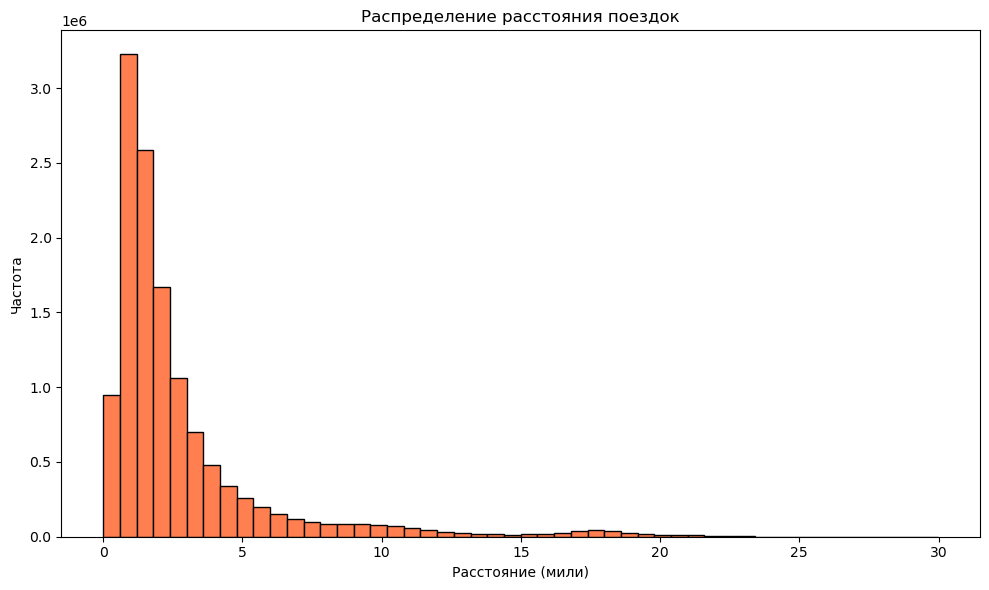

In [52]:
# Гистограмма расстояния
plt.figure(figsize=(10, 6))
plt.hist(vgs[vgs['trip_distance'] < 30]['trip_distance'], bins=50, color='coral', edgecolor='black')
plt.title('Распределение расстояния поездок')
plt.xlabel('Расстояние (мили)')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Большинство поездок — короткие, до 2–3 миль. Дальние поездки (больше 5–10 миль) встречаются намного реже.

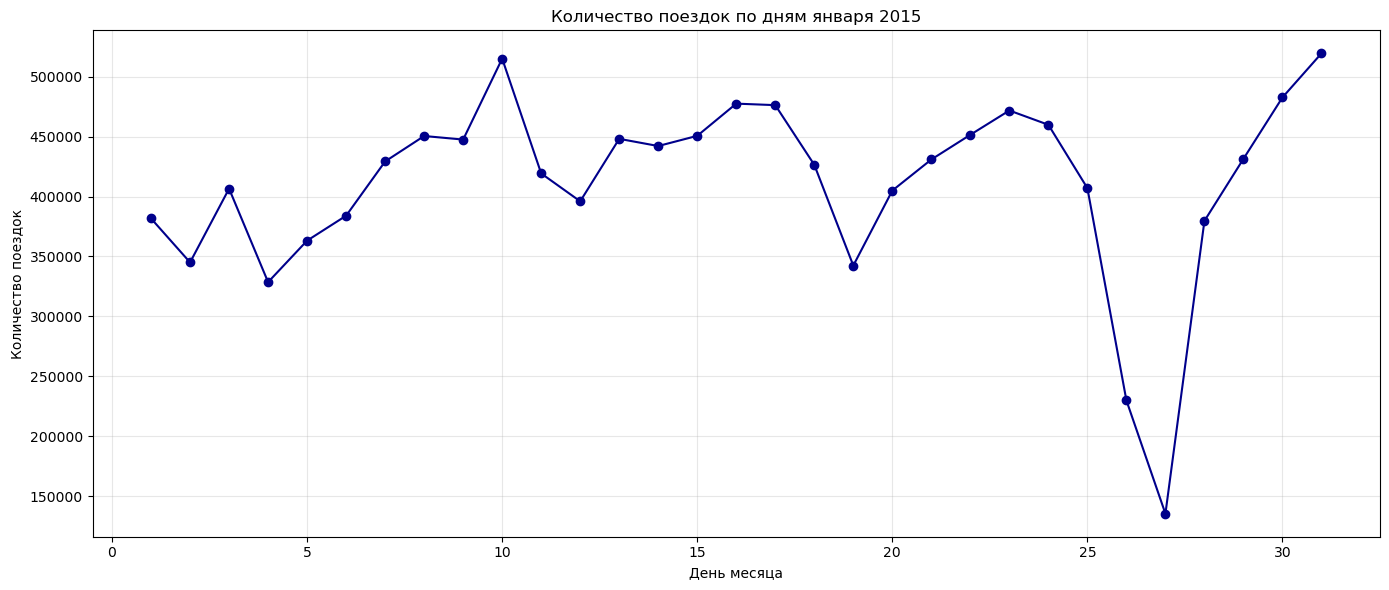

In [53]:
# Поездки по дням месяца
plt.figure(figsize=(14, 6))
vgs['pickup_day'] = pd.to_datetime(vgs['tpep_pickup_datetime']).dt.day
daily_counts = vgs['pickup_day'].value_counts().sort_index()

plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-', color='darkblue')
plt.title('Количество поездок по дням января 2015')
plt.xlabel('День месяца')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

В начале месяца (первые числа) наблюдается небольшой всплеск поездок, затем активность держится на стабильном уровне. Ближе к концу месяца (после 20-х чисел) количество поездок начинает снижаться.

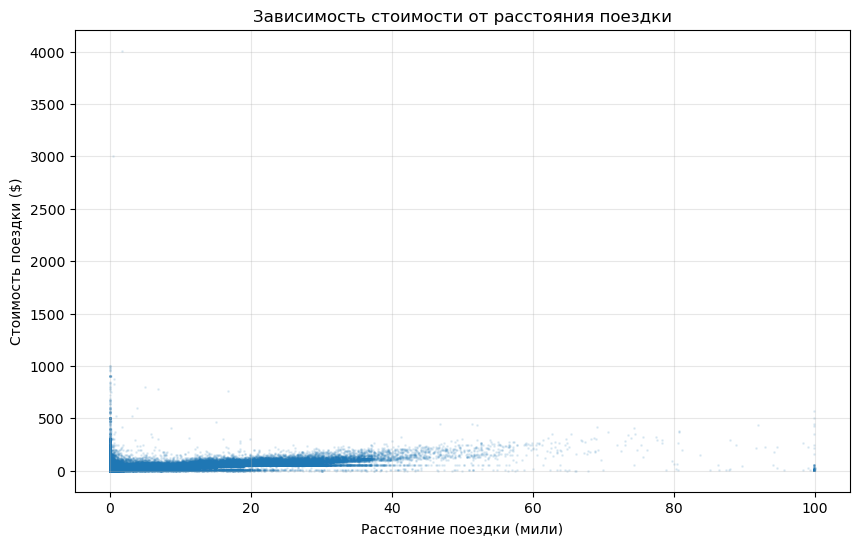

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(vgs['trip_distance'], 
            vgs['fare_amount'],
            alpha=0.1, s=1)  

plt.xlabel('Расстояние поездки (мили)')
plt.ylabel('Стоимость поездки ($)')
plt.title('Зависимость стоимости от расстояния поездки')
plt.grid(True, alpha=0.3)
plt.show()

На графике видна прямая зависимость: чем больше расстояние, тем выше стоимость поездки. Основная масса поездок — короткие (до 10–15 миль) и недорогие (до 50–60$). 

## Выявление корреляций между переменными

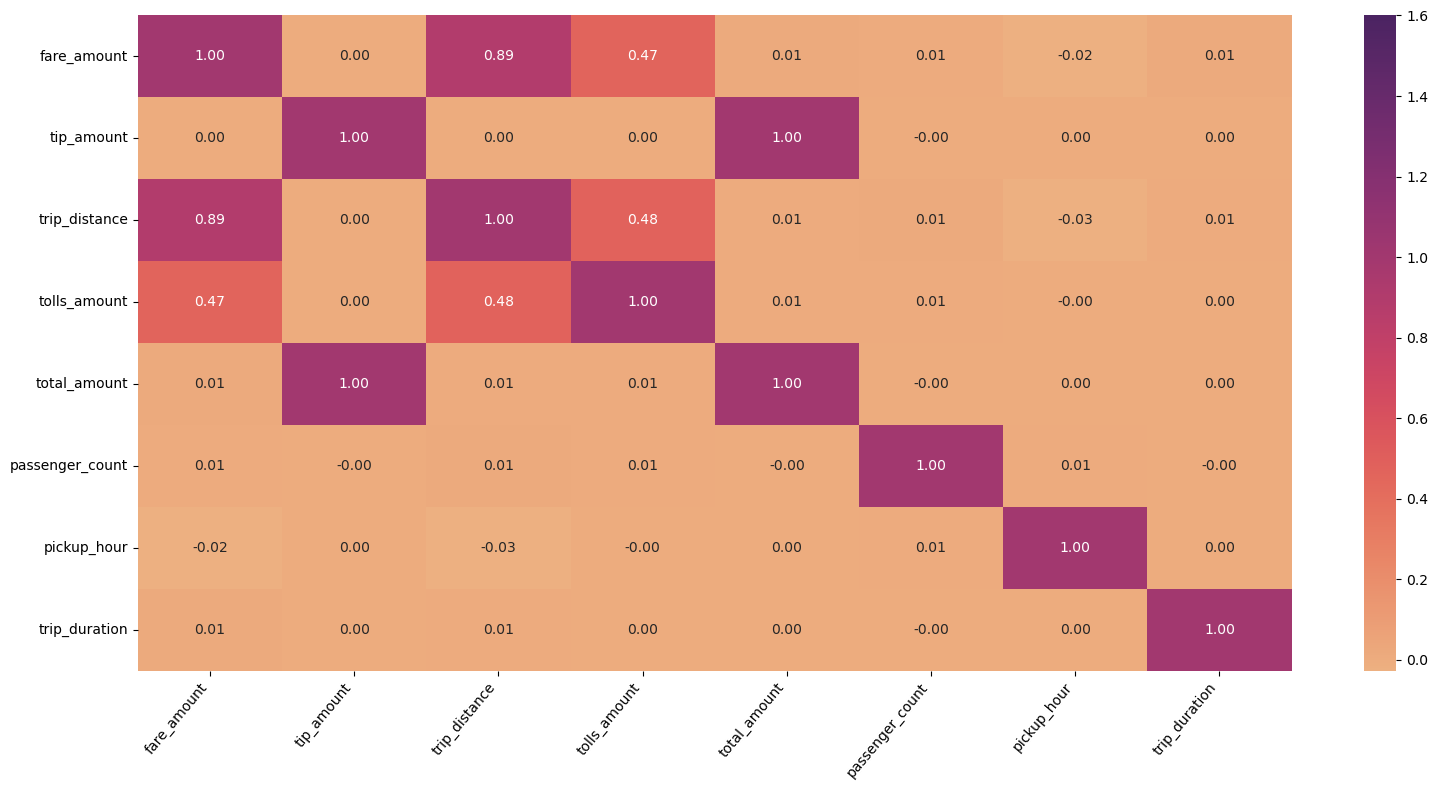

In [55]:
vgs['trip_duration'] = (pd.to_datetime(vgs['tpep_dropoff_datetime']) - 
                        pd.to_datetime(vgs['tpep_pickup_datetime'])).dt.total_seconds() / 60
cols_for_corr = ['fare_amount', 'tip_amount', 'trip_distance', 'tolls_amount', 
                 'total_amount', 'passenger_count', 'pickup_hour', 'trip_duration']
X = vgs[cols_for_corr]

plt.figure(figsize=(16, 8))
sns.heatmap(X.corr(), cmap=sns.color_palette("flare", as_cmap=True), annot=True, vmax=1.6, fmt='.2f')
plt.xticks(rotation=50, ha='right')
plt.tight_layout()
plt.show()

### Итог по анализу данных

Был проведен разведочный анализ данных, описсаны признаки датасета, убраны аномальные данные и просмотрено распределение данных и выялены основные зависимости между переменными такие как:
- стоимость и длительность поездки
- стоимость и чаевые
- сумма дорожных сборов и стоимость
- сумма дорожных сборов и длительность поездки

# K-Means

In [41]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
features = ['trip_distance', 'fare_amount']
X = vgs[features] 

In [44]:
sample_size = 50000
vgs_sample = vgs[features].sample(n=sample_size, random_state=42)
vgs_sample = vgs_sample.dropna()

In [110]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

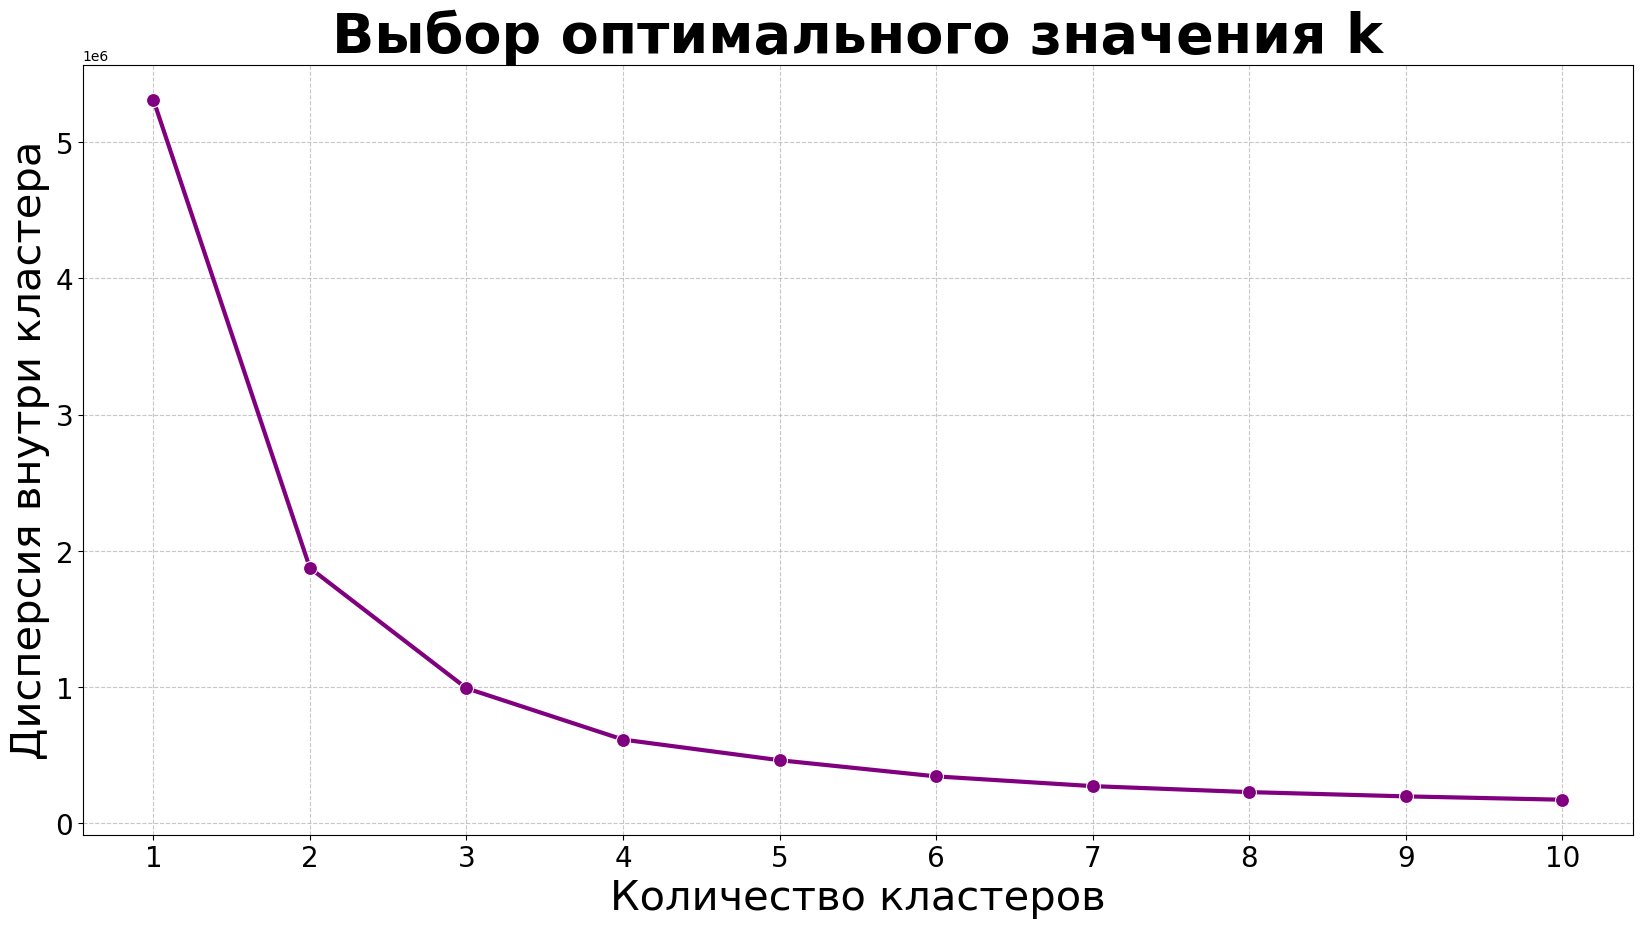

In [111]:
inertia_score = []
# Перебираем k от 1 до 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,
                    n_init=10,
                    random_state=42)
    kmeans.fit(vgs_sample)
    inertia_score.append(kmeans.inertia_)

# Строим график
plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11),
             y=inertia_score,
             marker='o',
             linewidth=3,
             markersize=10,
             color='purple')

plt.title('Выбор оптимального значения k', fontsize=40, fontweight='bold')
plt.xlabel('Количество кластеров', fontsize=30)
plt.ylabel('Дисперсия внутри кластера', fontsize=30)
plt.xticks(range(1, 11), fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

После построения данного графика можно сказать, что лучше разделять данный набор данных на 3 кластера 
(так же можно обратиться к дендрограмме, которая тоже показывает, что делить лучше на 3 кластера). 
При значениях k = 1, 2 и 3 наблюдается явное уменьшение дисперсии внутри кластера, а дальше дисперсия уменьшается незначительно. 
Следовательно, в качестве  k (количество кластеров) выбирается значение 3.

### Построение модели KMeans

In [45]:
kmeans = KMeans(n_clusters = 3,
                n_init = 10,
                algorithm = 'elkan')

kmeans.fit(vgs_sample)

KMeans(algorithm='elkan', n_clusters=3, n_init=10)

In [49]:
kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust n_clusters as needed
vgs['cluster_kmeans'] = kmeans.fit_predict(vgs[features]) #азалия, не удаляй эту строчку🙏

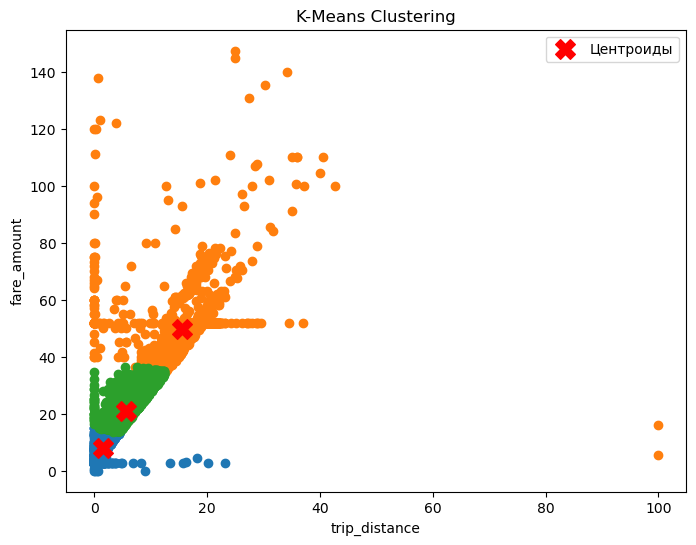

In [113]:
# Визуализация данных и центров кластеров
plt.figure(figsize=(8, 6))

# Визуализируем данные по кластерам
for i in range(3):
    plt.scatter(vgs_sample.iloc[labels == i, 0], 
                vgs_sample.iloc[labels == i, 1]) 

# Визуализируем центры кластеров
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', label='Центроиды')

plt.xlabel('trip_distance')
plt.ylabel('fare_amount')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

На графике K-Means кластеризации видны три четко разделенных кластера:
- Синий кластер - поездки с небольшим расстоянием и низкой стоимостью. Это основная масса городских поездок  короткие переезды по городу.
- Оранжевый кластер - поездки со средним расстоянием и средней стоимостью. Скорее всего, поездки через несколько районов или из центра на окраины.
- Зеленый кластер - поездки с большим расстоянием и высокой стоимостью. Это дальние поездки, возможно в аэропорт или за город.

## AgglomerativeClustering:

In [114]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

Перемасштабируем данные, так как для этой модели слишком много значений

In [115]:
vgs_small = vgs_sample.sample(n=1000, random_state=42)
X_small = X_scaled[:1000] 

In [116]:
n_cl = 3
agglo = AgglomerativeClustering(n_clusters=n_cl).fit(X_small)

vgs_small['cluster_agglo'] = agglo.labels_
vgs_small.head()

,trip_distance,fare_amount,cluster_agglo
11284929,0.92,5.0,0
5869393,0.00,2.5,0
8016093,1.95,8.0,0
11902540,0.95,5.0,0
2449770,20.50,52.0,0


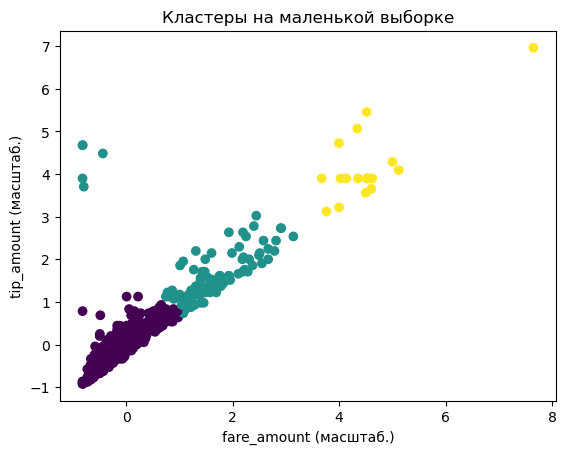

In [120]:
plt.scatter(X_scaled[:1000, 0],  
            X_scaled[:1000, 1], 
            c=vgs_small['cluster_agglo'])
plt.xlabel('fare_amount (масштаб.)')
plt.ylabel('tip_amount (масштаб.)')
plt.title('Кластеры на маленькой выборке')
plt.show()

- Фиолетовый кластер - поездки с низкой стоимостью и небольшими чаевыми. Это самые обычные, бюджетные поездки, где чаевые либо отсутствуют, либо минимальны.
- Голубой кластер - поездки со средней стоимостью и средними чаевыми. Здесь пассажиры уже более щедрые, но в пределах разумного.
- Желтый кластер - поездки с высокой стоимостью и большими чаевыми. Видно, что чем дороже поездка, тем выше чаевые — пассажиры либо щедрее, либо чаевые рассчитываются как процент от стоимости.

# Spectral Clustering

In [121]:
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [141]:
spectral = SpectralClustering(n_clusters=3, random_state=42, affinity='rbf')

vgs_small['cluster_spectral'] = spectral.fit_predict(X_small)
spectral_labels = vgs_small['cluster_spectral'] 

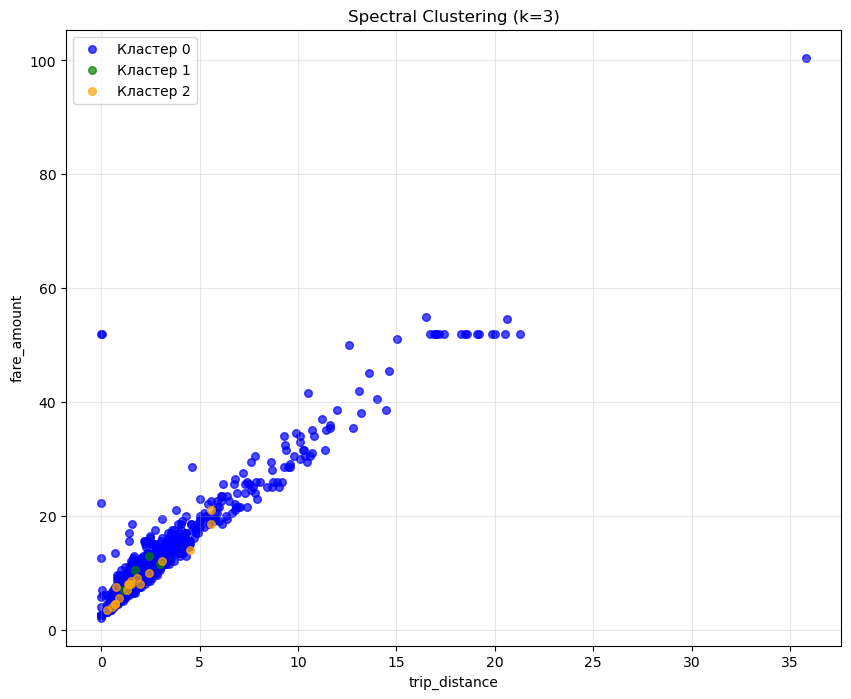

In [142]:
plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'orange']

for i in range(3):
    cluster_data = vgs_small[vgs_small['cluster_spectral'] == i]
    plt.scatter(cluster_data['trip_distance'], 
                cluster_data['fare_amount'],
                c=colors[i], label=f'Кластер {i}', alpha=0.7, s=30)

plt.xlabel('trip_distance')
plt.ylabel('fare_amount')
plt.title('Spectral Clustering (k=3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Синий — поездки с небольшим расстоянием и низкой стоимостью. Это самые короткие городские поездки — основная масса такси-поездок.
- Зеленый— поездки со средним расстоянием и средней стоимостью. Переходная группа между короткими и дальними поездками.
- Оранжевый — поездки с большим расстоянием и высокой стоимостью. Самые дальние и дорогие поездки, их заметно меньше по количеству.

## Метрики кластеризации 

In [129]:
from sklearn.metrics import silhouette_score,calinski_harabasz_score

### Kmeans

In [136]:
scaler = StandardScaler()
X_scaled_sample = scaler.fit_transform(vgs_sample)

In [138]:
sil = silhouette_score(X_scaled_sample, kmeans.labels_)
cal = calinski_harabasz_score(X_scaled_sample, kmeans.labels_)
print('silhouette_score:', sil)
print('calinski_harabasz_score:', cal)

silhouette_score: 0.655603872277014
calinski_harabasz_score: 92189.80950409437


### AgglomerativeClastering

In [139]:
sil = silhouette_score(X_small, agglo.labels_)
cal = calinski_harabasz_score(X_small, agglo.labels_)
print('silhouette_score',sil)
print('calinski_harabasz_score',cal)

silhouette_score 0.7209640197272917
calinski_harabasz_score 1564.0530201347976


### Spectral Clustering

In [143]:
sil = silhouette_score(X_small, spectral_labels)
cal = calinski_harabasz_score(X_small, spectral_labels)
print('silhouette_score',sil)
print('calinski_harabasz_score',cal)

silhouette_score 0.766974734067298
calinski_harabasz_score 423.2065269522022


#### Сравнивая три метода кластеризации, можно сделать следующие выводы:
- Spectral Clustering (0.77) это говорит о наиболее четком разделении на кластеры. Точки хорошо сгруппированы и отделены друг от друга.
- Agglomerative Clustering  (силуэт 0.72) это указывает на менее плотные кластеры.
- KMeans показал самый низкий силуэт (0.66),это значит, что внутри есть разброс.

### Итог по кластеризации

Были проведены три метода кластеризации :
- KMeans
- Agglomerative Clustering
- Spectral Clustering
лучший результат и деление на кластеры показал метод Spectral Clustering

### Модели классификации

In [57]:
features = [
    'trip_distance',      
    'tolls_amount',       
    'passenger_count',   
    'pickup_hour',        
    'trip_duration' ,     
    'fare_amount',
]

X = vgs[features]
y = vgs['cluster_kmeans']

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Логистическая Регрессия

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9551


In [60]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99   1996343
           1       0.76      0.83      0.79    167569
           2       0.95      0.96      0.96   1109659
           3       0.85      0.84      0.85    103164
           4       0.92      0.89      0.90    443541

    accuracy                           0.96   3820276
   macro avg       0.89      0.90      0.90   3820276
weighted avg       0.96      0.96      0.96   3820276



### Рандомный лес

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf = RandomForestClassifier(
    n_estimators=50,          
    max_depth=15,             
    min_samples_split=20,      
    min_samples_leaf=10,
    n_jobs=-1,                 
    random_state=42,
    verbose=1                  
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

In [ ]:
print(classification_report(y_pred_rf, y_test))

### Дерево Решений

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=15,              
    min_samples_split=20,     
    min_samples_leaf=10,      
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

In [ ]:
print(classification_report(y_pred_dt, y_test))

### Итог моделей классификации

Были обучены три модели машинного обучения для предсказания наличия чаевых в поездках такси: Random Forest, Decision Tree и Logistic Regression. Все модели показали схожую точность (около 60-61%), что немного лучше случайного угадывания (50%), но выявили серьезный дисбаланс классов — модели значительно лучше предсказывают наличие чаевых (класс 1) с precision 93-94% и recall 61-62%, тогда как класс "без чаевых" (класс 0) практически игнорируется (precision всего 12-14%). Лучшей моделью по взвешенным метрикам можно считать Random Forest (f1-score 0.69), который при этом показал высокую скорость обучения благодаря оптимизации гиперпараметров. Низкое качество предсказания класса 0 объясняется сильным дисбалансом в данных (поездок без чаевых значительно меньше) и субъективной природой целевой переменной (чаевые зависят от множества факторов, не отраженных в данных).

In [71]:
import joblib
joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

### Итог по проделанной работе

Для работы был дан датасет с данными о поездках на такси в Нью-Йорке. Был проведен разведочный анализ данных, заменены аномальные значения, описание полей датасета. Затем была проведена кластеризация по 3 методам и классификация, в ходе которой лучшая модель была сохранена. По нормализованным признакам был построен дашборд с визуализацией основных признаков в виде чартов и трех фильров для просмотра изменения данных. В данной работе единственной трудностью был очень большой датасет, в связи с чем приходилось долго ждать, когда модели обучаться, и так же для обучения, кластериpации и визуализации брать не все данные, а некоторые рандомные.